In [1]:
import os
import numpy as np
import torch
import time
import mlflow

from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import f1_score, accuracy_score
from dotenv import load_dotenv


from src.resnet import ResNet18
from src.inference import extract_features
from src.pca import PCATransformer
from src.draw_figures import *
from src.dataloader import build_excluded_dataset, get_dataset_config
from src.paths import DATA_DIR, FIGURES_DIR, MODELS_DIR, OUTPUT_DIR, ensure_dir


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
target = 9
epoch = 15

%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
mlflow.set_experiment("ResidualVariance")

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1782648903302, experiment_id='3', last_update_time=1782648903302, lifecycle_stage='active', name='test', tags={}>

### 1. Подготовка данных:

In [3]:
dataset_name = "cifar10"
dataset_config = get_dataset_config(dataset_name)
all_class_ids = list(range(dataset_config.num_classes))

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(dataset_config.mean, dataset_config.std)
])


generator = torch.Generator().manual_seed(seed)
output_dir = ensure_dir(OUTPUT_DIR / dataset_name / str(target)) 


### То, на чем обучаем resnet, строим pca
train_dataset = build_excluded_dataset(
    name=dataset_name,
    root=str(DATA_DIR),
    exclude_class=[target],
    train=True, 
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))

# выборка для построение PCA пространства, для тренеровки модели разделения
test_size = (len(train_dataset) - train_size - val_size) // 2 
# выбока, которая уйдет в финальный тест нового пайплайна
new_pipeline_test_size = len(train_dataset) - train_size - val_size - test_size


train, val, test, new_pipeline_test = random_split(
    train_dataset, 
    [train_size, val_size, test_size, new_pipeline_test_size], 
    generator=generator
)

train_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=2, generator=generator)
val_loader   = DataLoader(val, batch_size=64, shuffle=False, num_workers=2, generator=generator)
test_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=2, generator=generator)

### То, на чем делаем холостой (все классы будует неверные) предикт ради feature layer, на чем обучаем и проводим тесты lda
target_dataset = build_excluded_dataset(
    name=dataset_name,
    root=str(DATA_DIR),
    exclude_class=[class_id for class_id in all_class_ids if class_id != target],
    train=True, 
    transform=transform
)

target_train_size = int(0.85 * len(target_dataset))
target_test_size = (len(target_dataset) - target_train_size)
other = len(target_dataset) - target_train_size - target_test_size

train_target, test_target, other = random_split(
    target_dataset, 
    [target_train_size, target_test_size, other]
)

train_target_loader = DataLoader(train_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)
test_target_loader = DataLoader(test_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)

### То, на чем пробуем новый пайплайн
new_pipeline_loader = DataLoader(new_pipeline_test+test_target, batch_size=64, shuffle=True, num_workers=2, generator=generator)


In [4]:
load_dotenv()
mlflow.start_run(run_name=f"exclude_class_{target}_epoch{epoch}")

mlflow.log_params({
    "target": target,
    "seed": seed,
})

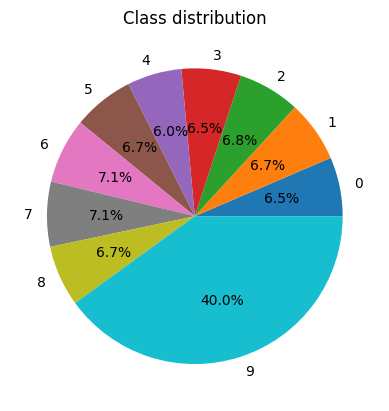

In [5]:
class_distr_path = class_distribution(
    new_pipeline_loader,
    str(output_dir / "new_pipeline_class_distribution.png")
)


mlflow.log_artifact(class_distr_path)

### 2. Подгружаем модель и извлекаем признаки:

In [6]:
resnet = ResNet18(
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=0.001,
        num_classes=dataset_config.num_classes,
        input_channels=dataset_config.input_channels,
        # num_epochs=8,
        weights=MODELS_DIR / f"resnet18_{dataset_name}_without{target}_epoch_{epoch}.pth"
    )

# history = resnet.train()

Loaded weights from /home/minin/workspace/ErrorCorrector/models/resnet18_cifar10_without9_epoch_15.pth


f1-мера (глобальные TP и FP): 0.7292136297454666, 
По каждому классу: [0.8        0.9        0.66932271 0.54723127 0.69230769 0.51923077
 0.80508475 0.78512397 0.84462151]


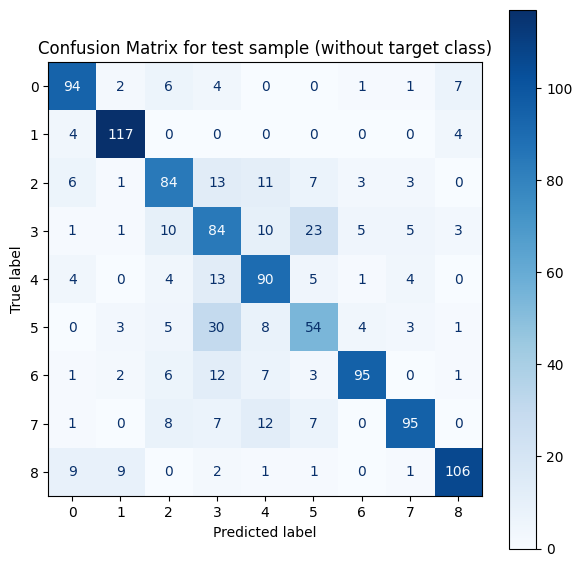

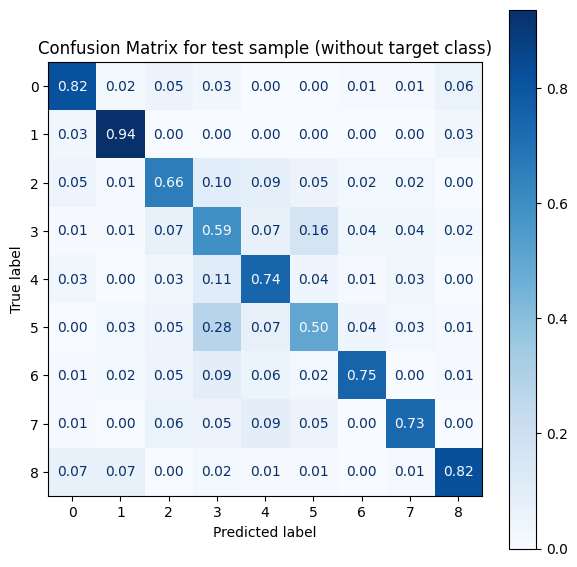

In [7]:
test_cifar9_features, test_cifar9_preds, test_cifar9_gt_preds = extract_features(resnet.model, test_loader, device)
test_cifar9_iscorrect = test_cifar9_gt_preds == test_cifar9_preds

mask = test_cifar9_gt_preds == test_cifar9_preds
test_cifar9_CR = test_cifar9_features[mask == True]
test_cifar9_WR = test_cifar9_features[mask == False]

test_cifar9_f1_score =  f1_score(test_cifar9_gt_preds, test_cifar9_preds, average="macro")
test_cifar9_f1_score_list = f1_score(test_cifar9_gt_preds, test_cifar9_preds, average=None)

print("f1-мера (глобальные TP и FP): {}, \nПо каждому классу: {}".format(
        test_cifar9_f1_score,
        test_cifar9_f1_score_list
    )
)
class_ids = [class_id for class_id in all_class_ids if class_id != target]
class_names = [str(class_id) for class_id in class_ids]


conf_martix_path = plot_confusion_matrix(
    test_cifar9_preds, 
    test_cifar9_gt_preds, 
    class_names=class_names,
    labels=class_ids,
    title="Confusion Matrix for test sample (without target class)",
    path=str(output_dir / "train" / "confusion_matrix.png")
)

# print(conf_martix_path)

conf_norm_martix_path = plot_confusion_matrix(
    test_cifar9_preds, 
    test_cifar9_gt_preds, 
    class_names=class_names,
    labels=class_ids,
    title="Confusion Matrix for test sample (without target class)",
    path=str(output_dir / "train" / "confusion_norm_matrix.png"),
    normalize="true"
)


In [8]:
mlflow.log_artifact(conf_martix_path, artifact_path="Test_loader") 
mlflow.log_artifact(conf_norm_martix_path, artifact_path="Test_loader") 

mlflow.log_metric("test_f1_macro", test_cifar9_f1_score)

for cls, f1 in zip(class_names, test_cifar9_f1_score_list):
        mlflow.log_metric(f"test_f1_class_{cls}", f1)

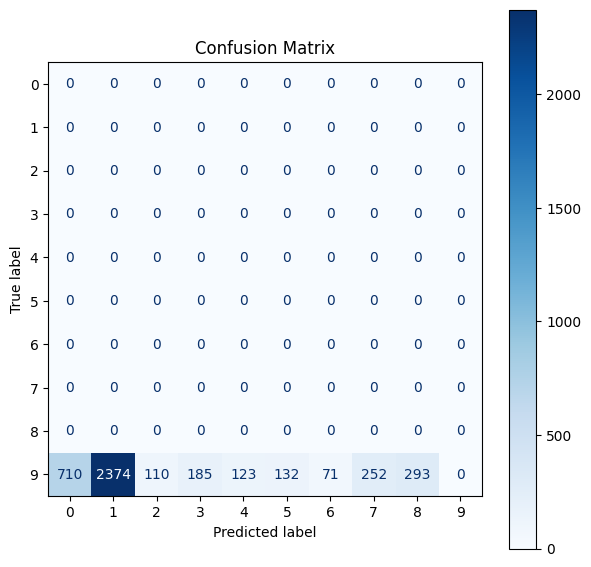

In [9]:
train_target_features, train_target_preds, train_target_gt_preds = extract_features(resnet.model, train_target_loader, device)

mask = train_target_gt_preds == train_target_preds
train_target_CR = train_target_features[mask == True]  
train_target_WR = train_target_features[mask == False] 

len(train_target_CR), len(train_target_WR)

plot_confusion_matrix(train_target_preds, train_target_gt_preds)

### 3. Разбираемся с PCA пространством и строем его проекции

Наша цель взять первые n компонент с большОй объясненной дисперсией, а затем взять чуть с меньшей и их вычесть
условно было $90$% и $80$% => нам интересно как будет себя вести модель на `хвосте` $10$% 

Финальное количество главных компонент: 100
Объяснённая дисперсия: 0.985
Выбран диапазон компонент [2:100] (дисперсия: 0.39
Форма хвоста: (819, 98)


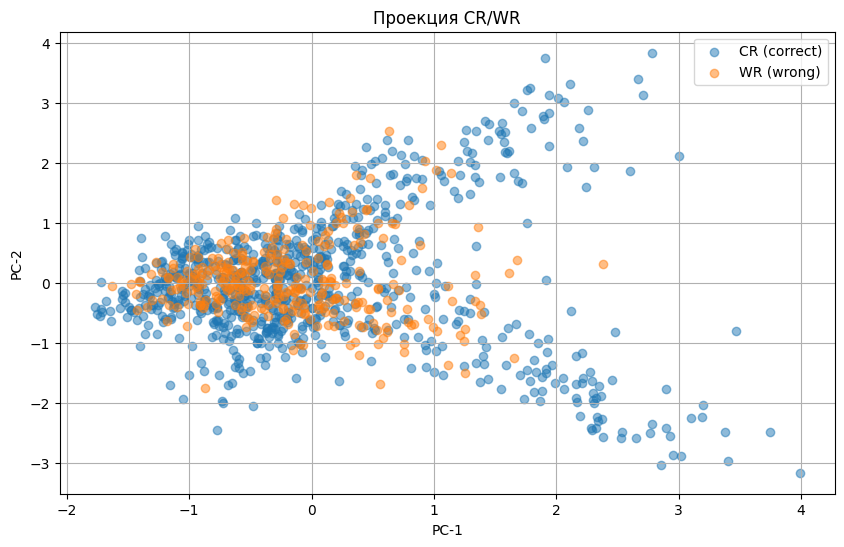

In [10]:
pca_full = PCATransformer(n_components=100, whiten=True)
pca_full.fit(test_cifar9_features)

_, _, tail_variance = pca_full.select_variance_range(0.60, 0.99)

# 3. Теперь transform() автоматически возвращает только "хвост"! 
test_cifar9_CR_tail = pca_full.transform(test_cifar9_CR)
test_cifar9_WR_tail = pca_full.transform(test_cifar9_WR)

print(f"Форма хвоста: {test_cifar9_CR_tail.shape}") 
pca_path = plot_projection(
    test_cifar9_CR_tail, 
    test_cifar9_WR_tail, 
    path=str(output_dir / "pca" / f"proj_variance{tail_variance}.png")
)
 

mlflow.log_artifact(pca_path, "PCA")

In [11]:
test_cifar9_features_tail = pca_full.transform(test_cifar9_features)

print("Проецирование всех test данных:")
plot_embedding_3d(test_cifar9_features_tail, test_cifar9_gt_preds.astype(str))

Проецирование всех test данных:


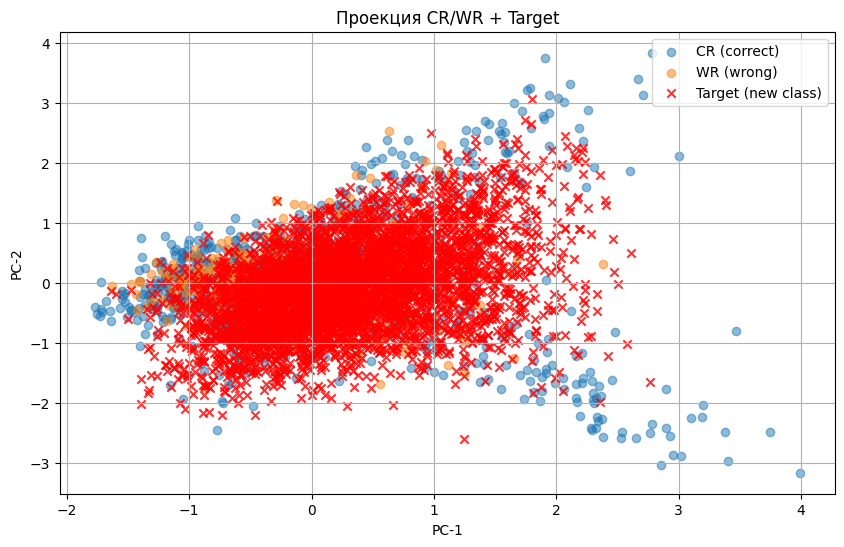

In [12]:
train_target_p = pca_full.transform(train_target_features)
target_pca_path = plot_projection(
    test_cifar9_CR_tail, 
    test_cifar9_WR_tail, 
    target_data=train_target_p,
    path=str(output_dir / "pca" / f"proj_with_target_variance{tail_variance}.png")
)

mlflow.log_artifact(target_pca_path, "PCA")

### 4. Сепарация

In [13]:
X_pca = np.vstack((test_cifar9_CR_tail, test_cifar9_WR_tail, train_target_p))

print(len(test_cifar9_CR_tail)+len(test_cifar9_WR_tail), len(train_target_p))
# 0 = старые классы (CR+WR), 1 = новый unseen класс
y_pca = np.hstack((
    np.zeros(len(test_cifar9_CR_tail) + len(test_cifar9_WR_tail)),
    np.ones(len(train_target_p))
))

1125 4250


#### 4.1 LDA

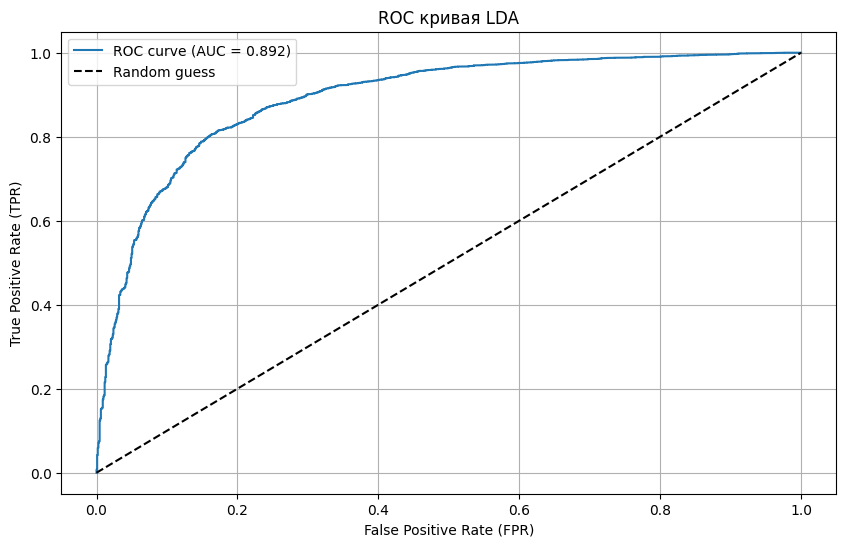

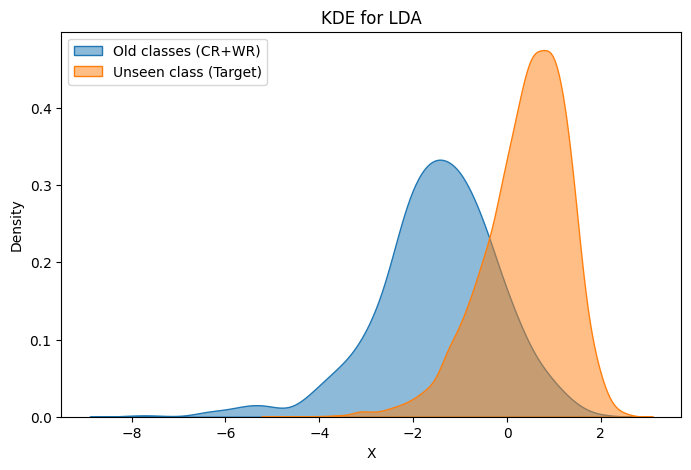

1

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# with timer("ROC/AUC for lda"):
lda_on_pca = LinearDiscriminantAnalysis(n_components=1)
X_pca_lda = lda_on_pca.fit_transform(X_pca, y_pca)


scores = X_pca_lda.ravel()  

# lda_pca_auc = plot_roc_auc(scores, y_pca, path=str(output_dir / "pca_roc_auc_for_lda.png"))
lda_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca,
    path=str(output_dir / "lda" / f"ROC_AUC_variance{tail_variance}.png")
)

kde_path = plot_kde(
    X_pca_lda, 
    y_pca, 
    path=str(output_dir / "lda" / f"kde_variance{tail_variance}.png")
)


mlflow.log_artifact(roc_auc_path, "lda")
mlflow.log_artifact(kde_path, "lda")
mlflow.log_metric(f"lda_auc_score_variance{tail_variance}", lda_pca_auc)
mlflow.log_param(f"lda_components_variance{tail_variance}", lda_on_pca.n_components)


####  Lineral SVM:

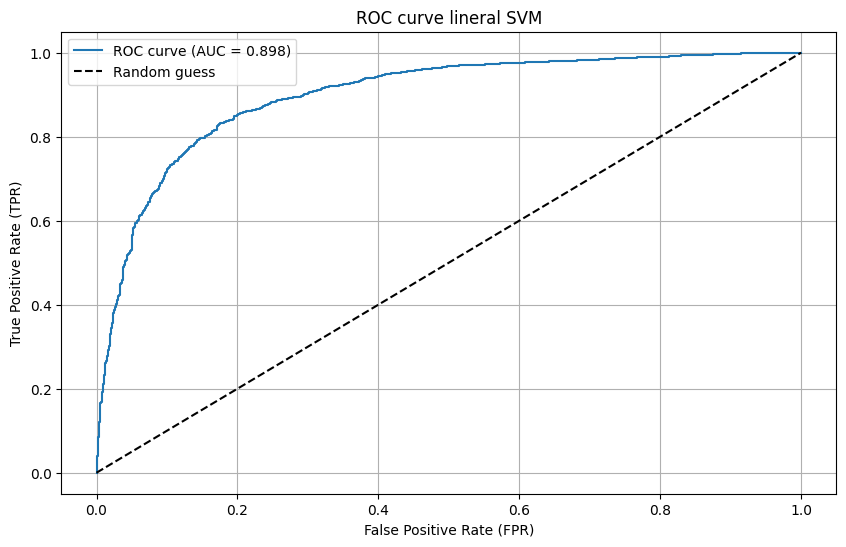

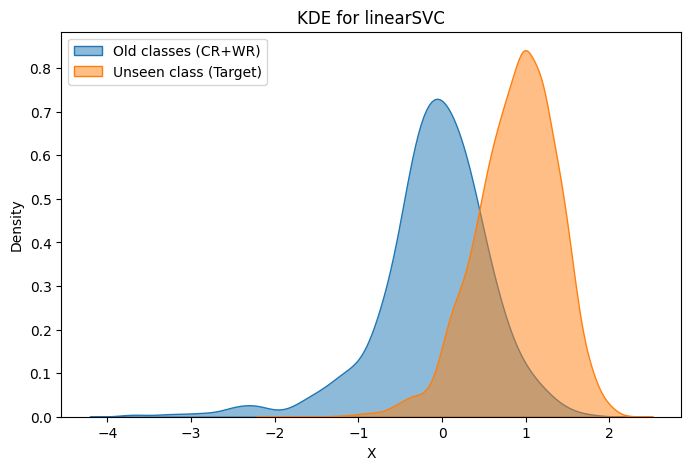

In [15]:
from sklearn.svm import LinearSVC

# with timer("ROC/AUC for LSVC"):
lsvc_on_pca = LinearSVC(dual=False)  
lsvc_on_pca.fit(X_pca, y_pca)

scores = lsvc_on_pca.decision_function(X_pca).ravel()

lsvc_pca_auc, roc_curve_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve lineral SVM",
    path=str(output_dir / "linearSVC" / f"ROC_AUC_variance{tail_variance}.png")
)

X_pca_svm = lsvc_on_pca.decision_function(X_pca).reshape(-1, 1)
kde_path = plot_kde(
    X_pca_svm, 
    y_pca,
    title="KDE for linearSVC",
    path=str(output_dir / "linearSVC" / f"kde_variance{tail_variance}.png")
)

mlflow.log_artifact(roc_auc_path, "linearSVC")
mlflow.log_artifact(kde_path, "linearSVC")
mlflow.log_metric(f"linearSVC_auc_score_variance{tail_variance}", lsvc_pca_auc)

#### Log Reg

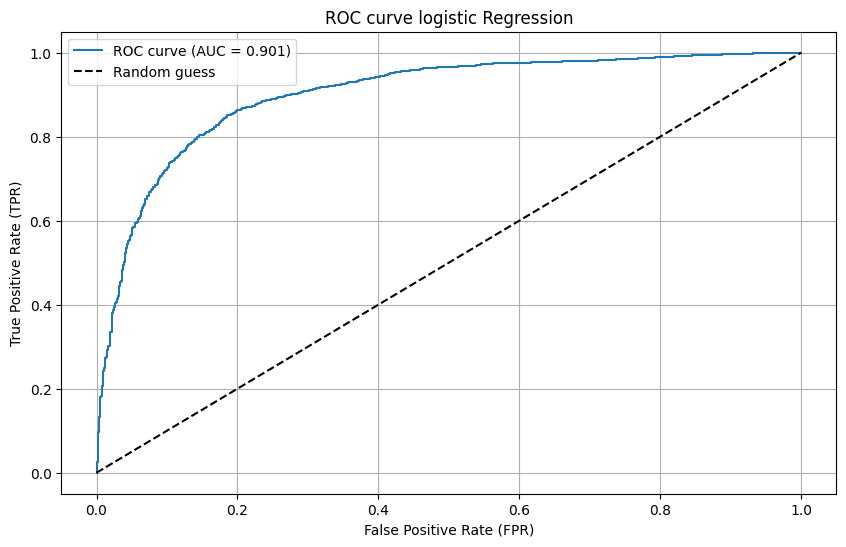

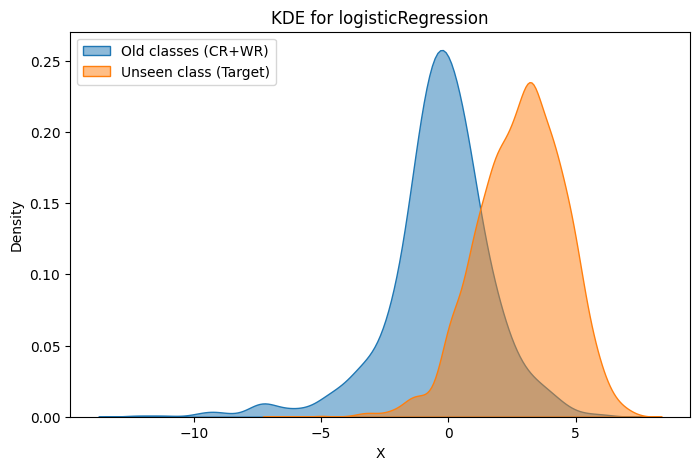

'liblinear'

In [16]:
from sklearn.linear_model import LogisticRegression

# LogisticRegression is supervised - uses labels like LDA and LinearSVC
# with timer("ROC/AUC for LR"):
lr_on_pca = LogisticRegression(solver='liblinear')
lr_on_pca.fit(X_pca, y_pca)

scores = lr_on_pca.decision_function(X_pca).ravel()

lr_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve logistic Regression",
    path=str(output_dir / "logisticRegression" / f"ROC_AUC_variance{tail_variance}.png")

)

X_pca_lr = lr_on_pca.decision_function(X_pca).reshape(-1, 1)
kde_path = plot_kde(
    X_pca_lr, 
    y_pca,
    title="KDE for logisticRegression",
    path=str(output_dir / "logisticRegression" / f"kde_variance{tail_variance}.png")
)

mlflow.log_artifact(roc_auc_path, "logisticRegression")
mlflow.log_artifact(kde_path, "logisticRegression")
mlflow.log_metric(f"logisticRegression_auc_score_variance{tail_variance}", lr_pca_auc)
mlflow.log_param(f"logisticRegression_solver_variance{tail_variance}", lr_on_pca.solver)

#### 4.4 RandomForest

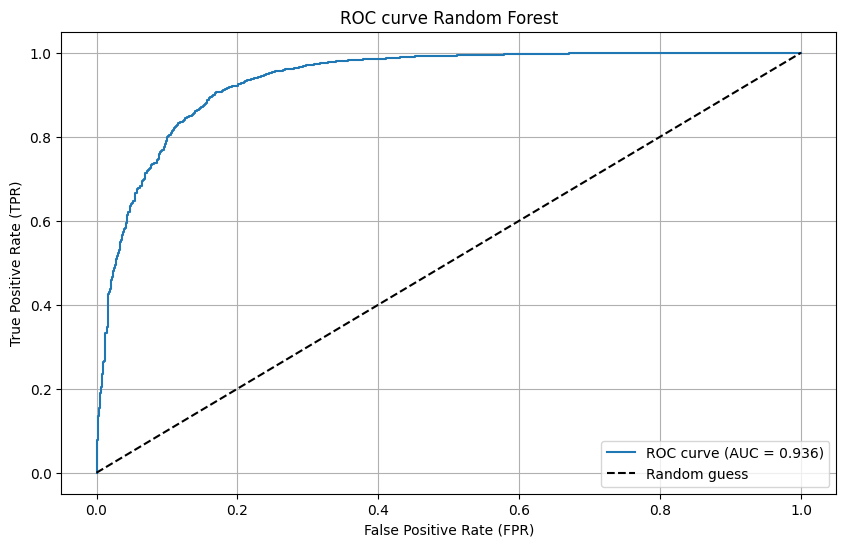

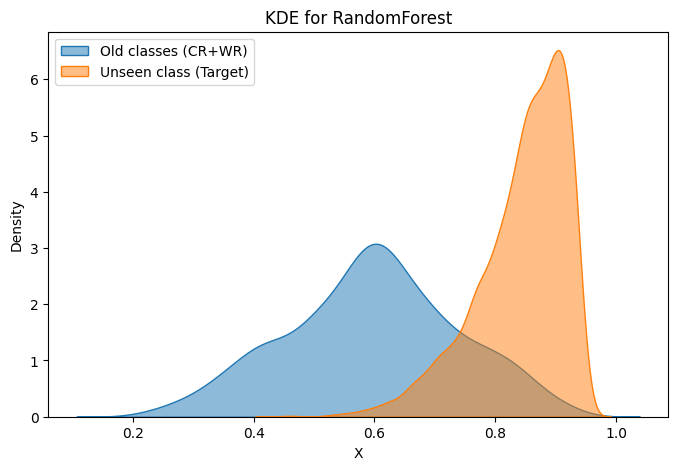

In [17]:
from sklearn.ensemble import RandomForestClassifier

# with timer("ROC/AUC for rf"):
rf_on_pca = RandomForestClassifier(
    n_estimators=50,                   
    max_depth=5,             
    # min_samples_split=10,     
    # min_samples_leaf=5,       
    # max_features='sqrt',       
    random_state=seed,           
    n_jobs=-1                 
)
rf_on_pca.fit(X_pca, y_pca)


scores = rf_on_pca.predict_proba(X_pca)[:, 1].ravel()

rf_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve Random Forest",
    path=str(output_dir / "randomForestClassifier" / f"ROC_AUC_variance{tail_variance}.png")
)

X_pca_rf = rf_on_pca.predict_proba(X_pca)[:, 1].reshape(-1, 1)
kde_path = plot_kde(
    X_pca_rf, 
    y_pca,
    title="KDE for RandomForest",
    path=str(output_dir / "randomForestClassifier" / f"kde_variance{tail_variance}.png")
)


mlflow.log_artifact(roc_auc_path, "randomForestClassifier")
mlflow.log_artifact(kde_path, "randomForestClassifier")
mlflow.log_metric(f"randomForestClassifier_auc_score_variance{tail_variance}", rf_pca_auc)
mlflow.log_params({
    f"randomForestClassifier_variance{tail_variance}": rf_on_pca.n_estimators,
    f"randomForestClassifier_variance{tail_variance}": rf_on_pca.max_depth,
})


#### 4.5 XGBoost:

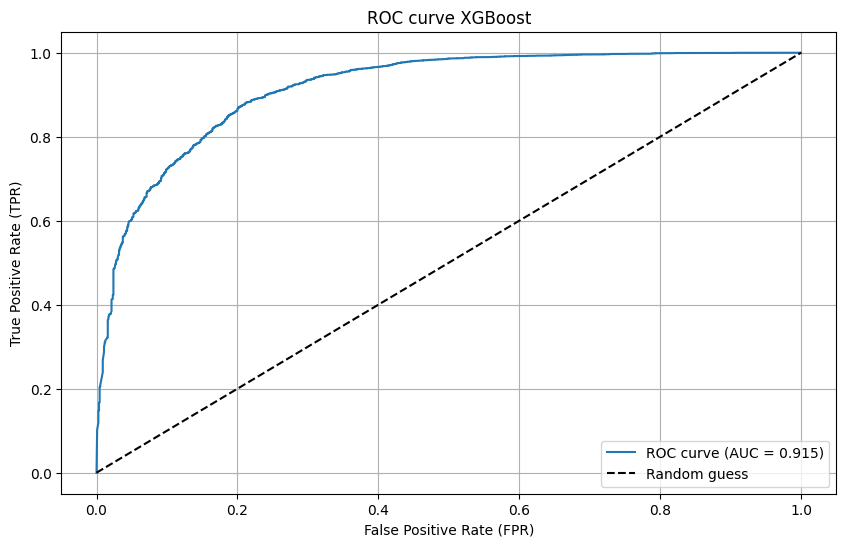

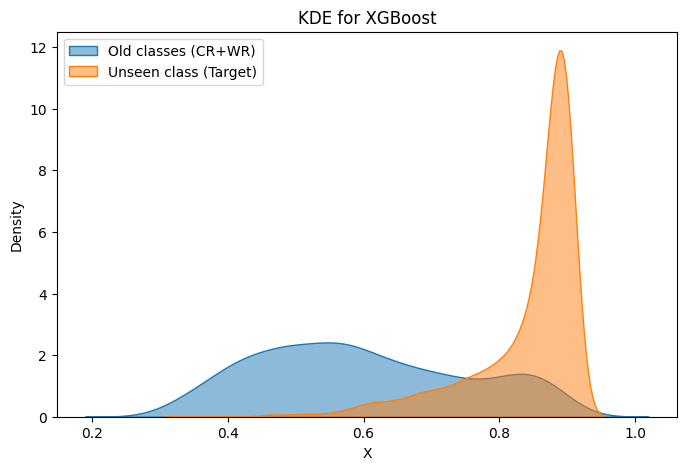

In [18]:
from xgboost import XGBClassifier

# with timer("ROC\AUC for xgb"):
xgb_on_pca = XGBClassifier(
    n_estimators=20,          # More trees to compensate for lower learning_rate
    max_depth=4,               # Reduced from 6 - shallower trees prevent overfitting
    learning_rate=0.05,        
    # subsample=0.7,            
    # colsample_bytree=0.7,     
    # min_child_weight=5,        
    # gamma=0.1,                
    # reg_alpha=0.5,           
    # reg_lambda=2.0,           
    random_state=seed,         
    n_jobs=-1,                
    # eval_metric='logloss'      
)
xgb_on_pca.fit(X_pca, y_pca)


scores = xgb_on_pca.predict_proba(X_pca)[:, 1].ravel()

xgb_pca_auc, roc_auc_path = plot_roc_auc(
    scores, 
    y_pca, 
    title="ROC curve XGBoost",
    path=str(output_dir / "xgbClassifier" / f"ROC_AUC_variance{tail_variance}.png")
)

X_pca_xgb = xgb_on_pca.predict_proba(X_pca)[:, 1].reshape(-1, 1)
kde_path = plot_kde(
    X_pca_xgb, 
    y_pca,
    title="KDE for XGBoost",
    path=str(output_dir / "xgbClassifier" / f"kde_variance{tail_variance}.png")
)

mlflow.log_artifact(roc_auc_path, "xgbClassifier")
mlflow.log_artifact(kde_path, "xgbClassifier")
mlflow.log_metric(f"xgbClassifier_auc_score_variance{tail_variance}", xgb_pca_auc)
mlflow.log_params({
    f"xgbClassifier_n_variance{tail_variance}": xgb_on_pca.n_estimators,
    f"xgbClassifier_max_depth_variance{tail_variance}": xgb_on_pca.max_depth,
    f"xgbClassifier_lr_variance{tail_variance}": xgb_on_pca.learning_rate,
    f"xgbClassifier_eval_metric_variance{tail_variance}": xgb_on_pca.eval_metric,
})

### 5. Новый пайлайн

In [19]:
all_classes = all_class_ids
features, preds, gt_preds = extract_features(resnet.model, new_pipeline_loader, device)

def new_pipeline(features: np.array, preds: np.array, sep_model, proj):
    features_p = proj.transform(features)


    # se_predict =  np.where(lda.predict_proba(features_p)[:, 1] > thresh, 1, 0)
    sep_predict = sep_model.predict(features_p)

    predict = []
    for i in range(sep_predict.shape[0]):
        if sep_predict[i]:
            predict.append(target)
        else:
            predict.append(preds[i])

    return np.array(predict)

def print_metric(preds, gt_preds):
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
    new_pipeline_loader_f1_score_macro = f1_score(gt_preds, preds, average="macro")
    new_pipeline_loader_f1_score_micro = f1_score(gt_preds, preds, average="micro")
    new_pipeline_loader_f1_score_list = f1_score(gt_preds, preds, average=None)
    new_pipeline_loader_acc = accuracy_score(gt_preds, preds)

    print("f1-мера (глобальные TP и FP): {} \nf1-score (усреднее): {}" \
    "\nf1-score (по каждому классу): {} \nacc: {}".format(
        new_pipeline_loader_f1_score_macro,
        new_pipeline_loader_f1_score_micro,
        new_pipeline_loader_f1_score_list,
        new_pipeline_loader_acc
        )
    )

    return new_pipeline_loader_f1_score_macro, new_pipeline_loader_f1_score_list


In [20]:
len(features)

1875

f1-мера (глобальные TP и FP): 0.5482106959540336 
f1-score (усреднее): 0.6288
f1-score (по каждому классу): [0.69811321 0.4278607  0.51546392 0.41836735 0.57142857 0.47916667
 0.68644068 0.40236686 0.57142857 0.71147044] 
acc: 0.6288


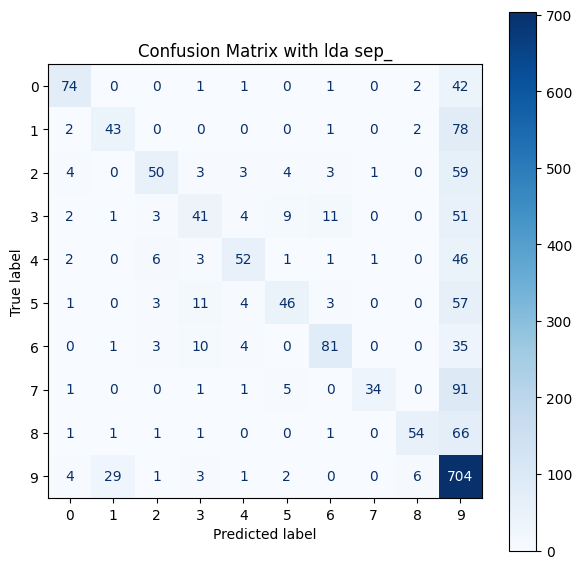

In [21]:
preds_pca = new_pipeline(features, preds, lda_on_pca, pca_full)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with lda sep_",
    path=str(output_dir / "lda" / f"new_pipeline_confusion_matrix_variance{tail_variance}.png")
)

mlflow.log_artifact(new_pipeline_conf_m, "lda")
mlflow.log_metric(f"new_pipeline_lda_f1_macro_variance{tail_variance}", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_lda_f1_class_{cls}_variance{tail_variance}", f1)

f1-мера (глобальные TP и FP): 0.5425053454607102 
f1-score (усреднее): 0.6261333333333333
f1-score (по каждому классу): [0.70697674 0.39790576 0.5492228  0.40641711 0.55555556 0.43478261
 0.67241379 0.42105263 0.57297297 0.70775348] 
acc: 0.6261333333333333


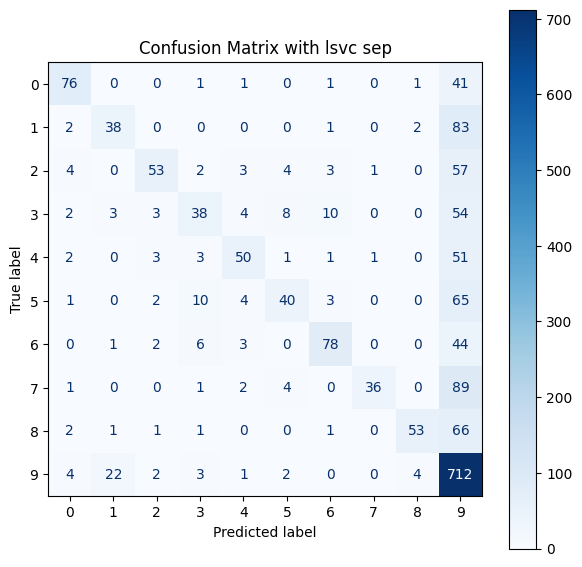

In [22]:
preds_pca = new_pipeline(features, preds, lsvc_on_pca, pca_full)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with lsvc sep",
    path=str(output_dir / "linearSVC" / f"new_pipeline_confusion_matrix_variance{tail_variance}.png")
)

mlflow.log_artifact(new_pipeline_conf_m, "linearSVC")
mlflow.log_metric(f"new_pipeline_linearSVC_f1_macro_variance{tail_variance}", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_linearSVC_f1_class_{cls}_variance{tail_variance}", f1)

f1-мера (глобальные TP и FP): 0.5489233100794622 
f1-score (усреднее): 0.6309333333333333
f1-score (по каждому классу): [0.69767442 0.41025641 0.55       0.39790576 0.57297297 0.45263158
 0.67521368 0.43678161 0.58064516 0.71515152] 
acc: 0.6309333333333333


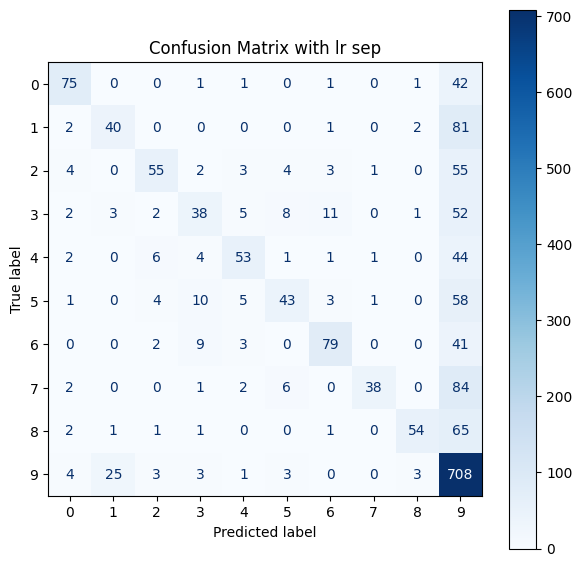

In [23]:
preds_pca = new_pipeline(features, preds, lr_on_pca, pca_full)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with lr sep",
    path=str(output_dir / "logisticRegression" / f"new_pipeline_confusion_matrix_variance{tail_variance}.png")
)

mlflow.log_artifact(new_pipeline_conf_m, "logisticRegression")
mlflow.log_metric(f"new_pipeline_logisticRegression_f1_macro_variance{tail_variance}", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_logisticRegression_f1_class_{cls}_variance{tail_variance}", f1)

f1-мера (глобальные TP и FP): 0.27326470939700676 
f1-score (усреднее): 0.49066666666666664
f1-score (по каждому классу): [0.24285714 0.0610687  0.46242775 0.20689655 0.50632911 0.0610687
 0.5        0.05839416 0.01587302 0.61773196] 
acc: 0.49066666666666664


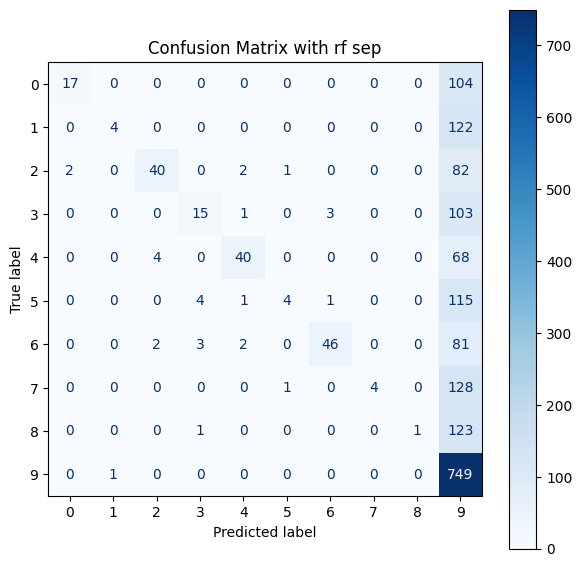

In [24]:
preds_pca = new_pipeline(features, preds, rf_on_pca, pca_full)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with rf sep",
    path=str(output_dir / "randomForestClassifier" / f"new_pipeline_confusion_matrix_variance{tail_variance}.png")
)

mlflow.log_artifact(new_pipeline_conf_m, "randomForestClassifier")
mlflow.log_metric(f"new_pipeline_randomForestClassifier_f1_macro_variance{tail_variance}", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_randomForestClassifier_f1_class_{cls}_variance{tail_variance}", f1)

f1-мера (глобальные TP и FP): 0.31523345812728476 
f1-score (усреднее): 0.5157333333333334
f1-score (по каждому классу): [0.24113475 0.01574803 0.5025641  0.35164835 0.4375     0.26666667
 0.60663507 0.05839416 0.03125    0.64079345] 
acc: 0.5157333333333334


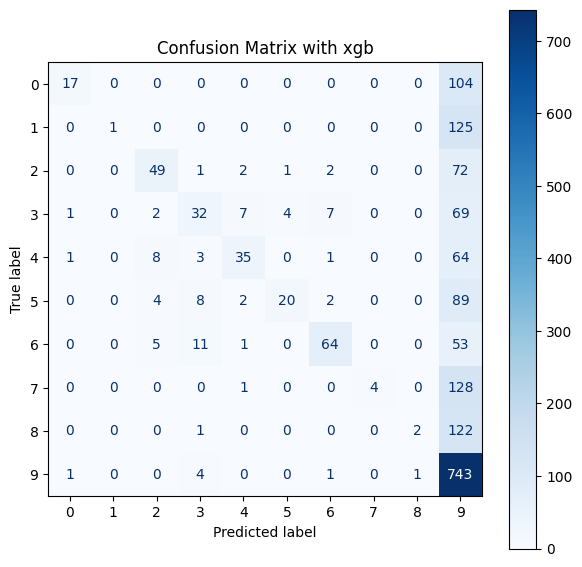

In [25]:
preds_pca = new_pipeline(features, preds, xgb_on_pca, pca_full)
new_pileine_f1_macro, new_pipeline_f1_list = print_metric(preds_pca, gt_preds)

new_pipeline_conf_m = plot_confusion_matrix(
    preds_pca, 
    gt_preds, 
    title="Confusion Matrix with xgb",
    path=str(output_dir / "xgbClassifier" / f"new_pipeline_confusion_matrix_variance{tail_variance}.png")
)

mlflow.log_artifact(new_pipeline_conf_m, "xgbClassifier")
mlflow.log_metric(f"new_pipeline_xgbClassifierr_f1_macro_variance{tail_variance}", new_pileine_f1_macro)
for cls, f1 in zip(all_classes, new_pipeline_f1_list):
        mlflow.log_metric(f"new_pipeline_xgbClassifier_f1_class_{cls}_variance{tail_variance}", f1)

In [26]:
mlflow.end_run()

🏃 View run exclude_class_9_epoch15 at: http://148.253.210.113:5000/#/experiments/3/runs/c4e058f65f424ea69d1a069a1c0c751f
🧪 View experiment at: http://148.253.210.113:5000/#/experiments/3
